# Visualization and Statistics: A Synthetic-Data Tour

## Part of the open_dvm Toolbox

This tutorial tours every plotting and statistical-testing option in `open_dvm.visualization.plot` -- `plot_erp_timecourse`, `plot_tfr_timecourse`, `plot_bdm_timecourse`, and `plot_ctf_timecourse` -- using **synthetic data with deliberately strong, reliable effects** rather than the project's real 7-subject dataset used from `01_preprocessing.ipynb` onward.

With only 7 real subjects, many genuine effects in the later tutorials may not reach statistical significance -- which is realistic, but makes it hard to tell "is this plot wrong" from "is this effect just underpowered." This notebook removes that ambiguity for the **`'easy'`** condition and the cross-condition (`cnd_diff`) comparisons: those are guaranteed significant by construction, so you can see exactly what a clean result looks like in each plot style. `'medium'`/`'hard'` are deliberately weaker and, tested on their own against zero/chance, may not reach significance by every method -- that's intentional, not a bug (see Section 1.2).

## Learning Objectives

After completing this tutorial, you will:

- **Generate synthetic, plot-ready data** -- Use `open_dvm.support.synthetic_data`'s generators to build ERP/TFR/BDM/CTF results with a known, time-window-bounded effect
- **Tour every 1D and 2D plotting mode** -- Timecourses, GAT matrices, time-frequency heatmaps, and CTF-specific views, across all four modalities
- **Compare statistical test methods** -- `stats='perm'` (cluster-based), `'ttest'` (uncorrected), and `'fdr'` (false-discovery-rate corrected)
- **Use condition-difference testing (`cnd_diff`)** -- Single and multi-contrast, with automatic per-timepoint coloring and 2D contour overlays
- **Distinguish visualization options from real analysis** -- `mask_nonsig`, `diverging_cmap`, `smooth`, and `show_SE`, independent of any specific research question

**Prerequisites:** None -- this notebook is self-contained and does not require preprocessed data. It's meant to be read *before* `01_preprocessing.ipynb`.

## Overview

### A Shared Synthetic Narrative

Every section below uses the same fictional three-condition design -- **easy**, **medium**, **hard** -- with a strong, time-window-bounded effect that is largest for `easy`, intermediate for `medium`, and weak/near-absent for `hard`. This isn't tied to any real experiment; it's purely a vehicle for guaranteed, clean `easy`-vs-`hard` (and multi-contrast `medium`-vs-`hard`) comparisons in every modality.

### Key Steps
1. **Setup**: Import `open_dvm`'s synthetic-data generators
2. **ERP options**: 1D waveforms, lateralization, stats methods, `cnd_diff`
3. **TFR options**: 2D heatmaps, `mask_nonsig`, contour overlays, `cnd_diff`
4. **BDM options**: 1D decoding, GAT, time-frequency decoding, multi-contrast `cnd_diff`
5. **CTF options**: 1D slopes, GAT/TFR CTF modes, `band_oi`, `cnd_diff`
6. **Summary**: What to look for once you move to real data in `01_preprocessing.ipynb`

## Section 1: Setup and Configuration

### 1.1 Import Required Libraries

In [1]:
# Enable inline plotting and suppress warnings
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import mne
import warnings
from IPython.display import display
warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

# Synthetic-data generators (shipped as part of open_dvm, not test-only code)
from open_dvm.support.synthetic_data import (
    make_condition_evokeds,
    make_average_tfr,
    make_bdm_result,
    make_ctf_result,
)

# The same four plotting functions used throughout the modality-specific tutorials
from open_dvm.visualization.plot import (
    plot_erp_timecourse,
    plot_tfr_timecourse,
    plot_bdm_timecourse,
    plot_ctf_timecourse,
)

print("✓ All imports successful!")

✓ All imports successful!


### 1.2 Why Synthetic Data, and How Much Effect Is "Enough"?

Each generator below builds data for `n_subjects` synthetic "subjects" with a **known, time-window-bounded effect**: flat/near-chance outside the window, and a strong, fixed offset inside it, plus independent Gaussian noise per subject. With `n_subjects=20` and the default effect sizes, the **`'easy'`** condition's effect reliably survives all three statistical tests (`'perm'`, `'ttest'`, `'fdr'`) against zero/chance -- this is a deliberate design choice for teaching, not a realistic effect size or sample size for an actual EEG study.

We'll reuse three condition labels throughout: **`'easy'`** (strong effect), **`'medium'`** (moderate effect), and **`'hard'`** (weak/near-absent effect). `'medium'`/`'hard'` are deliberately weaker and, tested individually against zero/chance, may not reach significance by every method (especially `'hard'`) -- what *is* guaranteed is the **`cnd_diff`** contrast between them: `'easy'` vs. `'hard'` (and `'medium'` vs. `'hard'` for the multi-contrast demo in Section 4) reliably differ from *each other*, which is what every section's condition-difference demo actually relies on.

### 1.3 Shared Configuration

In [2]:
# Shared configuration used throughout this notebook
N_SUBJECTS = 20            # far more than the real dataset's 7, for reliable stats
EFFECT_WINDOW = (30, 50)   # sample indices where the injected effect is present
COLORS = {'easy': 'red', 'medium': 'blue', 'hard': 'green'}

print(f"✓ Configuration set: {N_SUBJECTS} synthetic subjects, "
      f"effect window = samples {EFFECT_WINDOW}")

✓ Configuration set: 20 synthetic subjects, effect window = samples (30, 50)


---

## Section 2: ERP Plotting Options

**What you'll see**: a 1D lateralized ERP waveform (contra-minus-ipsi), all three statistical test methods compared side by side, and a condition-difference marker row.

`plot_erp_timecourse` is 1D-only -- there is no 2D mode for ERP data.

### 2.1 Generate Synthetic ERP Data

In [3]:
# Generate synthetic ERP data: easy/medium/hard conditions, each with a
# genuine contra-vs-ipsi amplitude difference inside EFFECT_WINDOW
erp_easy = make_condition_evokeds(
    contra_amp=6e-6, ipsi_amp=1e-6,       # strong lateralized effect
    effect_window=EFFECT_WINDOW, n_subjects=N_SUBJECTS, seed=1,
)
erp_medium = make_condition_evokeds(
    contra_amp=3.5e-6, ipsi_amp=1.5e-6,   # moderate lateralized effect
    effect_window=EFFECT_WINDOW, n_subjects=N_SUBJECTS, seed=2,
)
erp_hard = make_condition_evokeds(
    contra_amp=1.5e-6, ipsi_amp=1.3e-6,   # weak/near-absent effect
    effect_window=EFFECT_WINDOW, n_subjects=N_SUBJECTS, seed=3,
)

erps = {'easy': erp_easy, 'medium': erp_medium, 'hard': erp_hard}
times = erp_easy[0].times

print("✓ Synthetic ERP data generated for easy/medium/hard conditions")

✓ Synthetic ERP data generated for easy/medium/hard conditions


### 2.2 Lateralized Waveform: Comparing Statistical Test Methods

Same lateralized `'easy'` vs. `'hard'` comparison, tested three different ways. Each condition's own waveform is tested against zero (not against each other -- that's `cnd_diff`, in 2.3).

Times converted from seconds to milliseconds
Data for condition 'easy' converted from volts to microvolts
Data for condition 'hard' converted from volts to microvolts


Times converted from seconds to milliseconds
Data for condition 'easy' converted from volts to microvolts
Data for condition 'hard' converted from volts to microvolts
Times converted from seconds to milliseconds
Data for condition 'easy' converted from volts to microvolts
Data for condition 'hard' converted from volts to microvolts


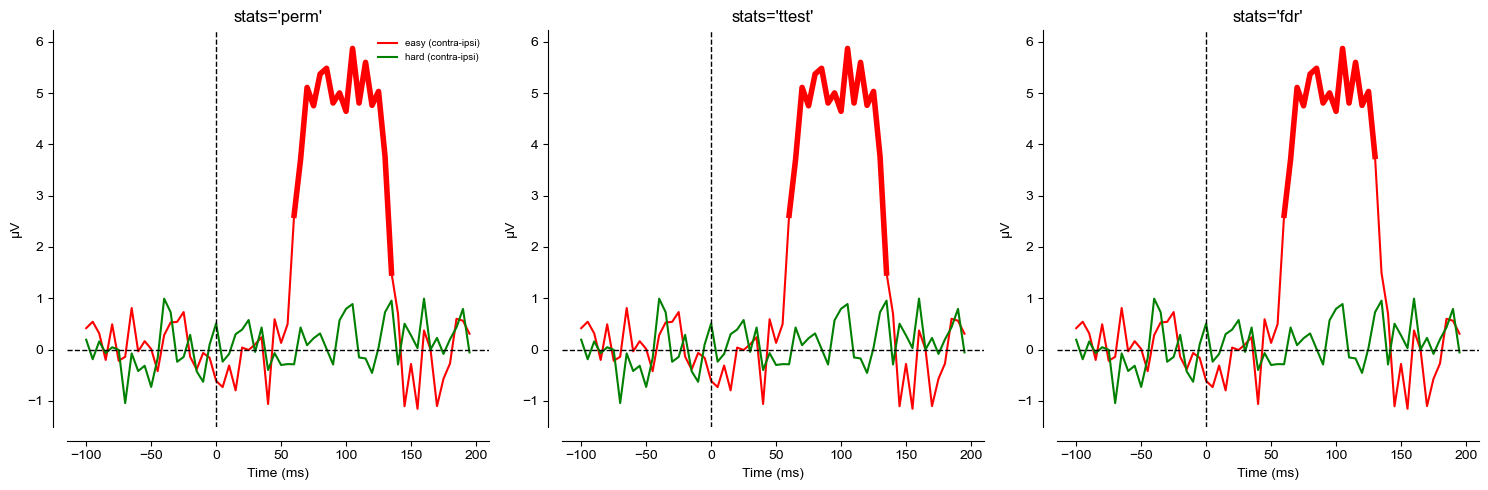

✓ All three statistical methods correctly find the strong 'easy' effect
  • 'perm': thick line segment over the cluster-corrected significant window
  • 'ttest': thick line segment over each individually-significant sample (no correction)
  • 'fdr': thick line segment over the FDR-corrected significant samples
  • 'hard' is deliberately weak and may show little or no significant segment by
    any method here -- that's expected; its role is the cnd_diff comparison next


In [4]:
# Compare all three statistical test methods on the same lateralized effect
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, method in zip(axes, ['perm', 'ttest', 'fdr']):
    plt.sca(ax)
    plot_erp_timecourse(
        {'easy': erp_easy, 'hard': erp_hard}, times,
        elec_oi=[['C3', 'C5'], ['C4', 'C6']],    # [contra group, ipsi group]
        lateralized=True,                        # plot contra-minus-ipsi
        cnds=['easy', 'hard'],                   # Conditions to compare
        colors=[COLORS['easy'], COLORS['hard']], # Fixed color per condition (see COLORS above)
        stats=method,                            # test each condition vs. zero
        show_legend=(method == 'perm'),          # Only show legend once (first subplot)
    )
    ax.set_title(f"stats='{method}'")

plt.tight_layout()
display(fig)
plt.close('all')

print("✓ All three statistical methods correctly find the strong 'easy' effect")
print("  • 'perm': thick line segment over the cluster-corrected significant window")
print("  • 'ttest': thick line segment over each individually-significant sample (no correction)")
print("  • 'fdr': thick line segment over the FDR-corrected significant samples")
print("  • 'hard' is deliberately weak and may show little or no significant segment by")
print("    any method here -- that's expected; its role is the cnd_diff comparison next")

### 2.3 Condition-Difference Marker (`cnd_diff`)

Is `'easy'` significantly different from `'hard'`, rather than each being different from zero? Since both conditions are lateralized (one waveform per condition) and both have assigned colors, the marker row below auto-colors by whichever condition is higher at each timepoint.

Times converted from seconds to milliseconds
Data for condition 'easy' converted from volts to microvolts


Data for condition 'hard' converted from volts to microvolts


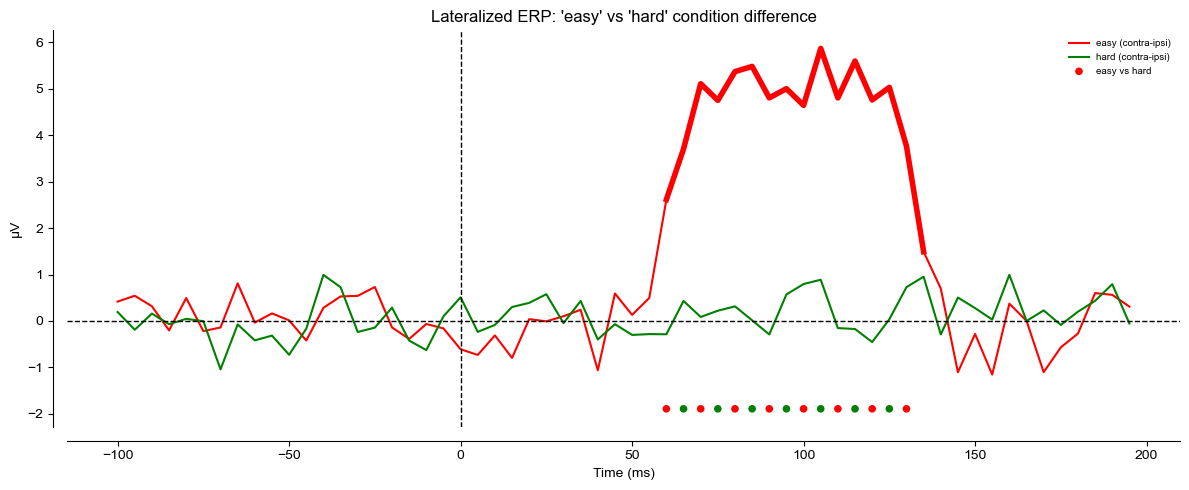

✓ Marker row below the waveforms shows where 'easy' and 'hard' differ
  significantly, auto-colored red/green by whichever is higher at each timepoint


In [5]:
fig = plt.figure(figsize=(12, 5))
plot_erp_timecourse(
    erps, times,
    elec_oi=[['C3', 'C5'], ['C4', 'C6']],     # [contra group, ipsi group]
    lateralized=True,                         # Plot contra-minus-ipsi
    cnds=['easy', 'hard'],                    # Conditions to compare
    colors=[COLORS['easy'], COLORS['hard']],  # Fixed color per condition (see COLORS above)
    stats='perm',                             # Cluster-based permutation test (each condition vs. zero)
    cnd_diff=('easy', 'hard'),                # Also test whether the two conditions differ from each other
)
plt.title("Lateralized ERP: 'easy' vs 'hard' condition difference")
plt.tight_layout()
display(fig)
plt.close('all')

print("✓ Marker row below the waveforms shows where 'easy' and 'hard' differ")
print("  significantly, auto-colored red/green by whichever is higher at each timepoint")

---

## Section 3: TFR Plotting Options

**What you'll see**: a 2D time-frequency heatmap with `mask_nonsig`, a 1D frequency-band timecourse, and both the 1D-marker and 2D-contour styles of `cnd_diff`.

### 3.1 Generate Synthetic TFR Data

In [6]:
# Alpha-band (8-12 Hz) lateralized power effect, same easy/medium/hard design
tfr_easy = make_average_tfr(
    contra_amp=3.0, ipsi_amp=0.3, effect_window=EFFECT_WINDOW,
    effect_freq_range=(8, 12), n_subjects=N_SUBJECTS, seed=1,
)
tfr_medium = make_average_tfr(
    contra_amp=1.8, ipsi_amp=0.6, effect_window=EFFECT_WINDOW,
    effect_freq_range=(8, 12), n_subjects=N_SUBJECTS, seed=2,
)
tfr_hard = make_average_tfr(
    contra_amp=0.8, ipsi_amp=0.6, effect_window=EFFECT_WINDOW,
    effect_freq_range=(8, 12), n_subjects=N_SUBJECTS, seed=3,
)
tfr_data = {'easy': tfr_easy, 'medium': tfr_medium, 'hard': tfr_hard}

print("✓ Synthetic TFR data generated (alpha-band, 8-12 Hz effect)")

✓ Synthetic TFR data generated (alpha-band, 8-12 Hz effect)


### 3.2 2D Heatmap with `mask_nonsig`

Times converted from seconds to milliseconds


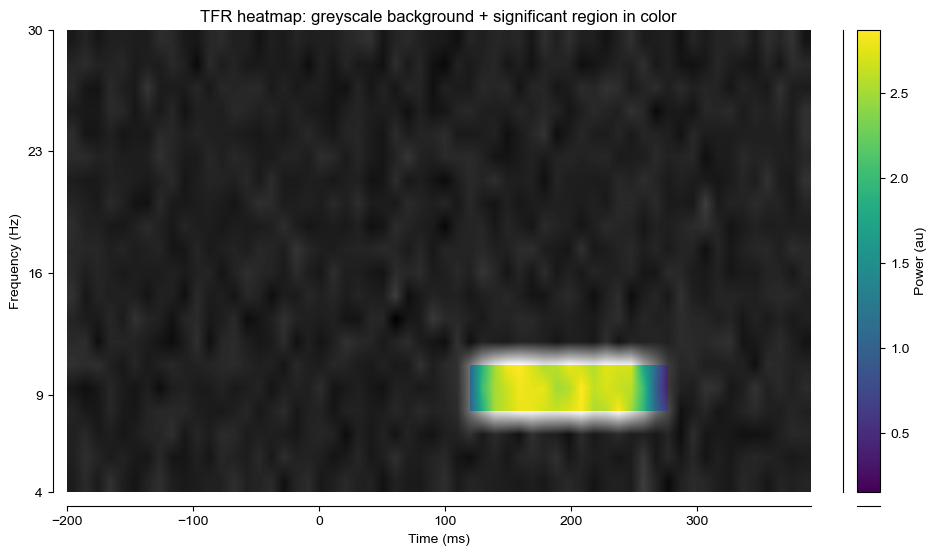

✓ mask_nonsig=True shows the full data in greyscale, with only the
  statistically significant time-frequency region shown in color


In [7]:
# 2D time-frequency heatmap: full data in greyscale + significant region in color
fig = plt.figure(figsize=(12, 6))
plot_tfr_timecourse(
    tfr_data,
    elec_oi=[['C3', 'C5'], ['C4', 'C6']],  # [contra group, ipsi group]
    lateralized=True,                      # Plot contra-minus-ipsi difference
    cnds=['easy'],                         # 2D mode only supports one condition
    timecourse='2d',                       # Full time-frequency heatmap
    stats='perm',                          # Cluster-based permutation test vs. zero
    mask_nonsig=True,                      # Grey out non-significant time-frequency points
)
plt.title("TFR heatmap: greyscale background + significant region in color")
display(fig)
plt.close('all')

print("✓ mask_nonsig=True shows the full data in greyscale, with only the")
print("  statistically significant time-frequency region shown in color")

### 3.3 1D Frequency-Band Timecourse

Times converted from seconds to milliseconds


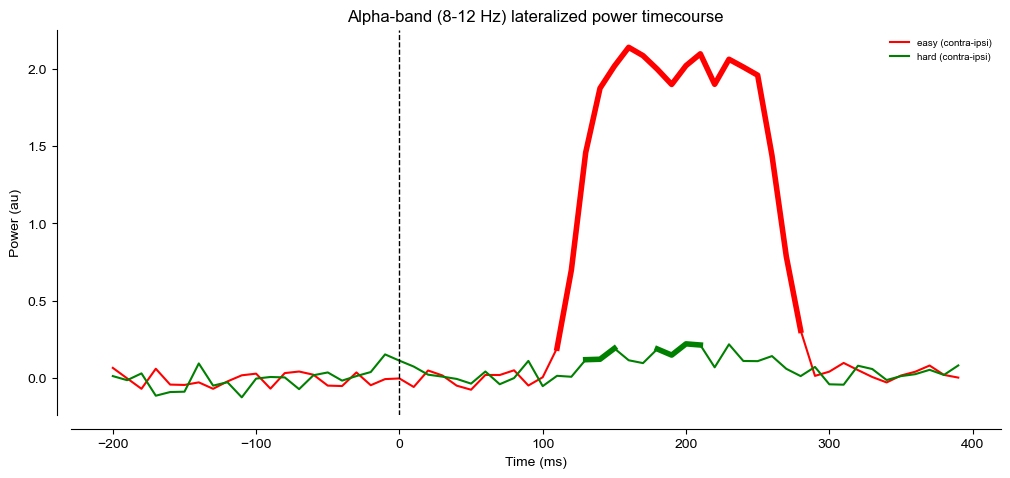

In [8]:
fig = plt.figure(figsize=(12, 5))
plot_tfr_timecourse(
    tfr_data,
    elec_oi=[['C3', 'C5'], ['C4', 'C6']],     # [contra group, ipsi group]
    lateralized=True,                         # Plot contra-minus-ipsi difference
    cnds=['easy', 'hard'],                    # Conditions to compare
    colors=[COLORS['easy'], COLORS['hard']],  # Fixed color per condition (see COLORS above)
    timecourse='1d',                          # 1D timecourse (averaged over frequency)
    freq_oi=(8, 12),                          # Average within the alpha band
    stats='perm',                             # Cluster-based permutation test vs. zero
)
plt.title("Alpha-band (8-12 Hz) lateralized power timecourse")
display(fig)
plt.close('all')

### 3.4 Condition-Difference: 1D Marker and 2D Contour

Times converted from seconds to milliseconds


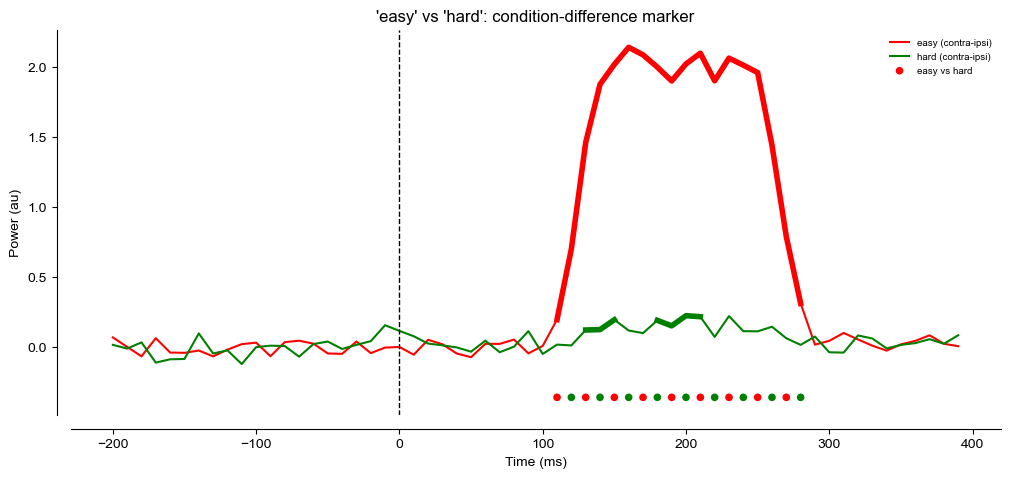

Times converted from seconds to milliseconds


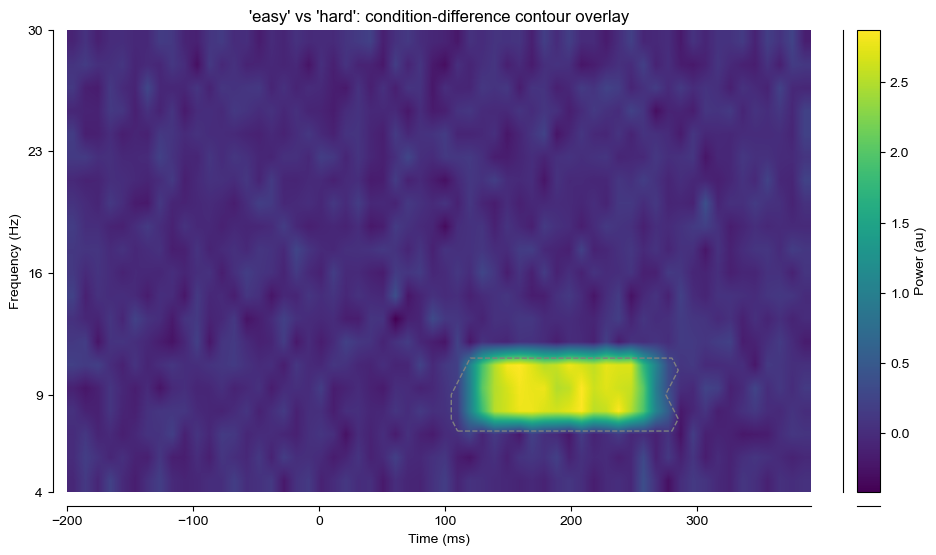

✓ cnd_diff overlays a dashed contour outline on the existing heatmap,
  showing exactly where the two conditions differ significantly


In [9]:
# 1D: marker row
fig1 = plt.figure(figsize=(12, 5))
plot_tfr_timecourse(
    tfr_data,
    elec_oi=[['C3', 'C5'], ['C4', 'C6']],     # [contra group, ipsi group]
    lateralized=True,                         # Plot contra-minus-ipsi difference
    cnds=['easy', 'hard'],                    # Conditions to compare
    colors=[COLORS['easy'], COLORS['hard']],  # Fixed color per condition (see COLORS above)
    timecourse='1d',                          # 1D timecourse (averaged over frequency)
    freq_oi=(8, 12),                          # Average within the alpha band
    stats='perm',                             # Cluster-based permutation test vs. zero
    cnd_diff=('easy', 'hard'),                # Also test whether the two conditions differ
)
plt.title("'easy' vs 'hard': condition-difference marker")
display(fig1)

# 2D: dashed contour outline drawn on top of the existing heatmap
fig2 = plt.figure(figsize=(12, 6))
plot_tfr_timecourse(
    tfr_data,
    elec_oi=[['C3', 'C5'], ['C4', 'C6']],  # [contra group, ipsi group]
    lateralized=True,                      # Plot contra-minus-ipsi difference
    cnds=['easy'],                         # 2D mode only supports one condition
    timecourse='2d',                       # Full time-frequency heatmap
    stats='perm',                          # Cluster-based permutation test vs. zero
    cnd_diff=('easy', 'hard'),             # Overlay contour where 'easy' and 'hard' differ
)
plt.title("'easy' vs 'hard': condition-difference contour overlay")
display(fig2)
plt.close('all')

print("✓ cnd_diff overlays a dashed contour outline on the existing heatmap,")
print("  showing exactly where the two conditions differ significantly")

---

## Section 4: BDM Plotting Options

**What you'll see**: a 1D decoding timecourse, a **multi-contrast** `cnd_diff` (two condition-difference tests stacked in one figure), a Generalization-Across-Time (GAT) matrix with a diverging colormap, and time-frequency decoding.

### 4.1 Generate Synthetic BDM Data

In [10]:
bdm_easy = make_bdm_result(peak_auc=0.85, effect_window=EFFECT_WINDOW,
                           n_subjects=N_SUBJECTS, cnd='easy', seed=1)
bdm_medium = make_bdm_result(peak_auc=0.68, effect_window=EFFECT_WINDOW,
                              n_subjects=N_SUBJECTS, cnd='medium', seed=2)
bdm_hard = make_bdm_result(peak_auc=0.53, effect_window=EFFECT_WINDOW,
                            n_subjects=N_SUBJECTS, cnd='hard', seed=3)

# merge into one list of per-subject dicts holding all three conditions
# (sequential .update() avoids a duplicate-'info'-keyword collision that
# dict(a, **b, **c) would raise when b and c share the 'info' key)
bdms = []
for e, m, h in zip(bdm_easy, bdm_medium, bdm_hard):
    merged = dict(e)
    merged.update(m)
    merged.update(h)
    bdms.append(merged)

print("✓ Synthetic BDM decoding data generated for easy/medium/hard")

✓ Synthetic BDM decoding data generated for easy/medium/hard


### 4.2 1D Decoding Timecourse

Times converted from seconds to milliseconds


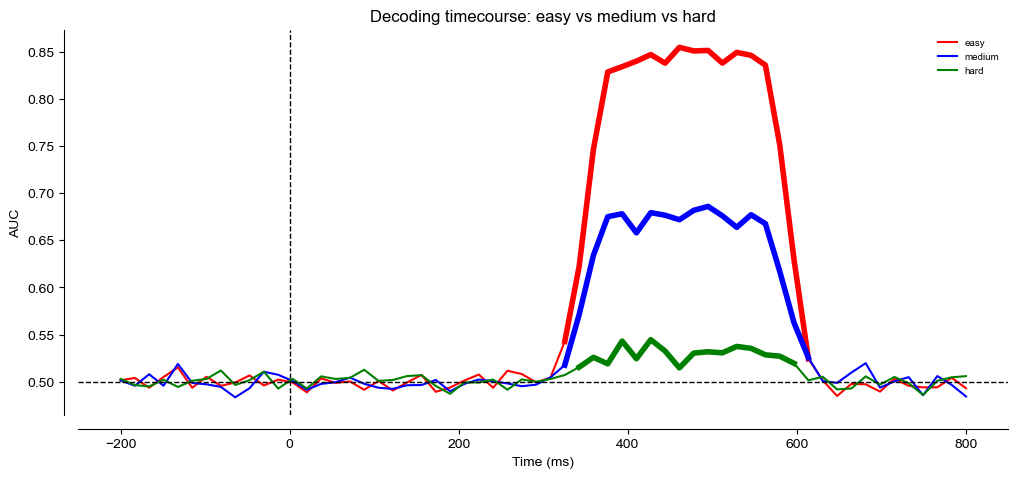

In [11]:
fig = plt.figure(figsize=(12, 5))
plot_bdm_timecourse(
    bdms,
    cnds=['easy', 'medium', 'hard'],                            # All three conditions
    colors=[COLORS['easy'], COLORS['medium'], COLORS['hard']],  # Fixed color per condition
    stats='perm',                                               # Cluster-based permutation test vs. chance
)
plt.title("Decoding timecourse: easy vs medium vs hard")
display(fig)
plt.close('all')

### 4.3 Multi-Contrast Condition-Difference

`cnd_diff` accepts a *list* of contrasts -- each gets its own auto-stacked row below the plot, so overlapping-in-time contrasts stay visually distinguishable.

Times converted from seconds to milliseconds


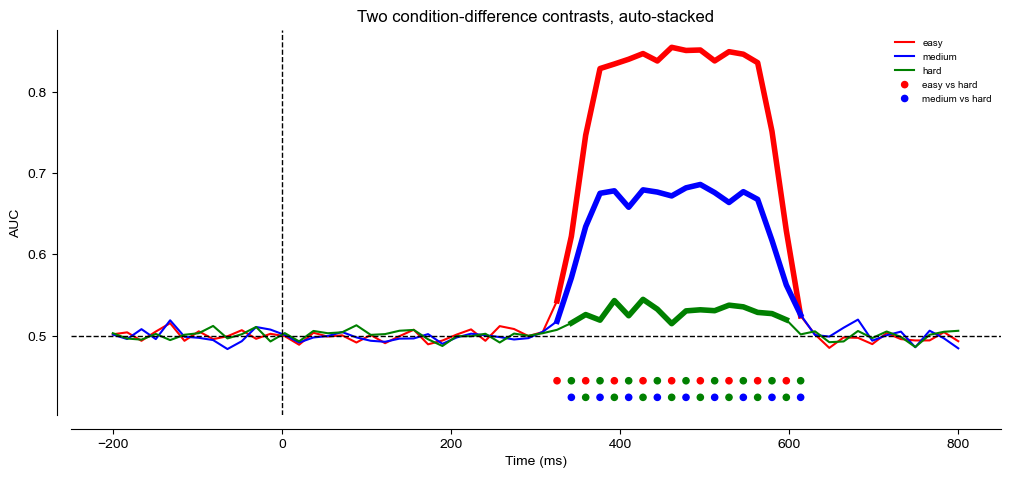

✓ Each contrast gets its own row below the plot, auto-colored by
  whichever condition is higher at each timepoint


In [12]:
fig = plt.figure(figsize=(12, 5))
plot_bdm_timecourse(
    bdms,
    cnds=['easy', 'medium', 'hard'],                            # All three conditions
    colors=[COLORS['easy'], COLORS['medium'], COLORS['hard']],  # Fixed color per condition
    stats='perm',                                               # Cluster-based permutation test vs. chance
    cnd_diff=[('easy', 'hard'), ('medium', 'hard')],            # Two contrasts, each auto-stacked below the plot
)
plt.title("Two condition-difference contrasts, auto-stacked")
display(fig)
plt.close('all')

print("✓ Each contrast gets its own row below the plot, auto-colored by")
print("  whichever condition is higher at each timepoint")

### 4.4 Generalization Across Time (GAT) with `diverging_cmap`

Times converted from seconds to milliseconds


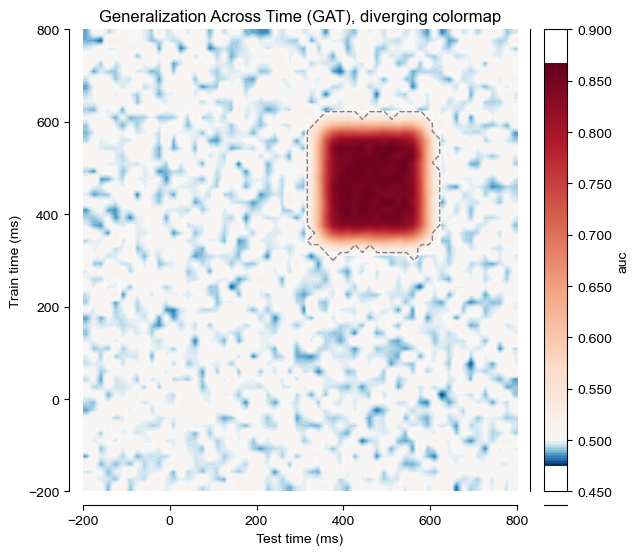

✓ diverging_cmap centers the colormap at chance level (0.5), so above-
  and below-chance decoding are immediately visually distinguishable


In [13]:
gat_easy = make_bdm_result(peak_auc=0.85, shape='gat', effect_window=EFFECT_WINDOW,
                           n_subjects=N_SUBJECTS, cnd='easy', seed=1)
gat_hard = make_bdm_result(peak_auc=0.53, shape='gat', effect_window=EFFECT_WINDOW,
                           n_subjects=N_SUBJECTS, cnd='hard', seed=3)
bdms_gat = [dict(e, **h) for e, h in zip(gat_easy, gat_hard)]

fig = plt.figure(figsize=(7, 6))
plot_bdm_timecourse(
    bdms_gat,
    cnds=['easy'],               # 2D mode only supports one condition
    timecourse='2d_GAT',         # Generalization matrix (train time x test time)
    diverging_cmap=True,         # Diverging colormap centered at chance (0.5)
    stats='perm',                # Cluster-based permutation test vs. chance
    cnd_diff=('easy', 'hard'),   # Overlay contour where 'easy' and 'hard' differ
)
plt.title("Generalization Across Time (GAT), diverging colormap")
display(fig)
plt.close('all')

print("✓ diverging_cmap centers the colormap at chance level (0.5), so above-")
print("  and below-chance decoding are immediately visually distinguishable")

### 4.5 Time-Frequency Decoding

Times converted from seconds to milliseconds


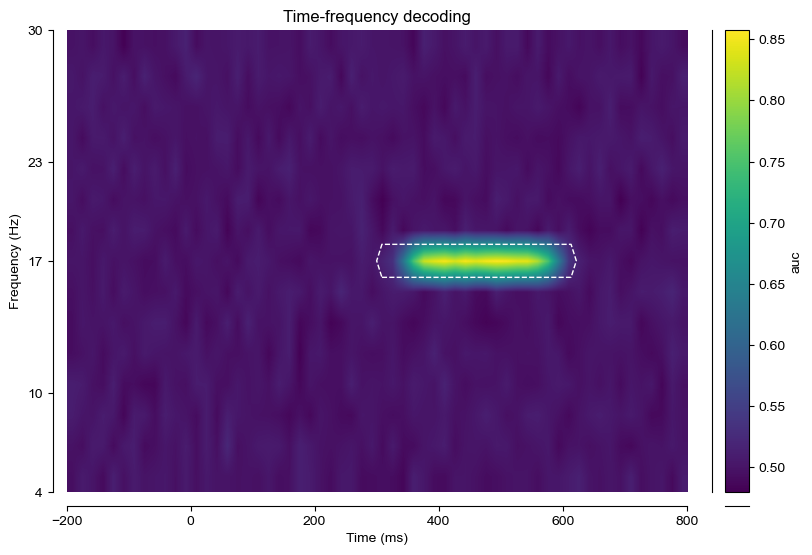

In [14]:
tfr_bdm_easy = make_bdm_result(peak_auc=0.85, shape='tfr', effect_window=EFFECT_WINDOW,
                               n_subjects=N_SUBJECTS, cnd='easy', seed=1)

fig = plt.figure(figsize=(10, 6))
plot_bdm_timecourse(
    tfr_bdm_easy,
    cnds=['easy'],          # 2D mode only supports one condition
    timecourse='2d_tfr',    # 2D time-frequency heatmap (time x frequency)
    stats='perm',           # Cluster-based permutation test vs. chance
)
plt.title("Time-frequency decoding")
display(fig)
plt.close('all')

---

## Section 5: CTF Plotting Options

**What you'll see**: a 1D tuning-slope timecourse with `cnd_diff`, `band_oi` selection, GAT/TFR CTF modes.

### 5.1 Generate Synthetic CTF Data

In [15]:
ctf_easy = make_ctf_result(peak_slope=0.03, effect_window=EFFECT_WINDOW,
                           n_subjects=N_SUBJECTS, cnd='easy', seed=1)
ctf_medium = make_ctf_result(peak_slope=0.018, effect_window=EFFECT_WINDOW,
                              n_subjects=N_SUBJECTS, cnd='medium', seed=2)
ctf_hard = make_ctf_result(peak_slope=0.004, effect_window=EFFECT_WINDOW,
                            n_subjects=N_SUBJECTS, cnd='hard', seed=3)

ctfs = []
for e, m, h in zip(ctf_easy, ctf_medium, ctf_hard):
    merged = dict(e)
    merged.update(m)
    merged.update(h)
    ctfs.append(merged)

print("✓ Synthetic CTF tuning-slope data generated for easy/medium/hard")

✓ Synthetic CTF tuning-slope data generated for easy/medium/hard


### 5.2 1D Slope Timecourse with `cnd_diff`

Times converted from seconds to milliseconds


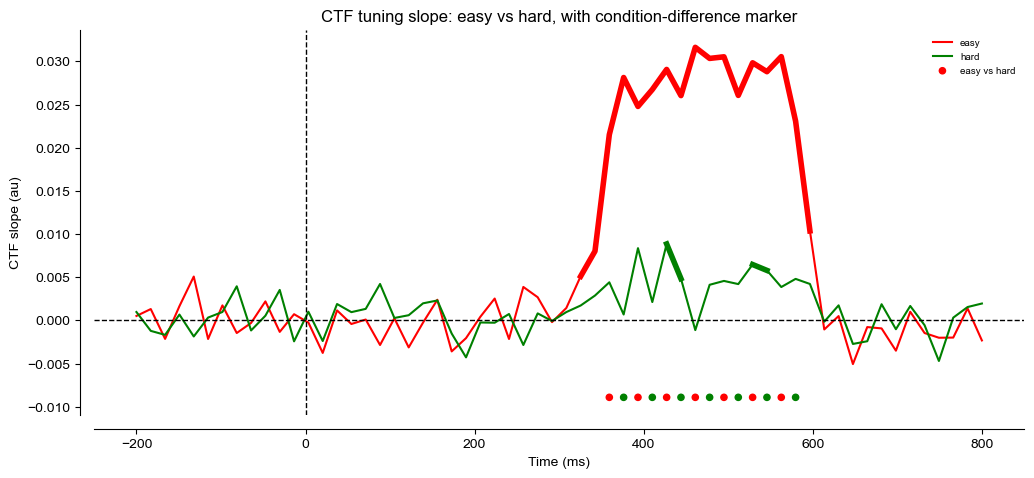

In [16]:
fig = plt.figure(figsize=(12, 5))
plot_ctf_timecourse(
    ctfs,
    cnds=['easy', 'hard'],                    # Conditions to compare
    colors=[COLORS['easy'], COLORS['hard']],  # Fixed color per condition (see COLORS above)
    output='raw_slopes',                      # Un-fitted linear tuning slope
    stats='perm',                             # Cluster-based permutation test vs. zero
    cnd_diff=('easy', 'hard'),                # Also test whether the two conditions differ
)
plt.title("CTF tuning slope: easy vs hard, with condition-difference marker")
display(fig)
plt.close('all')

### 5.3 `band_oi` Selection

`band_oi` selects a single named frequency band out of multiple, rather than averaging across all of them. This synthetic example ties the same effect to every band (the generator's `shape='1d'` mode doesn't differentiate bands), so both bands look identical here -- with real multi-band data, `band_oi` typically reveals genuinely different tuning profiles per band.

Times converted from seconds to milliseconds


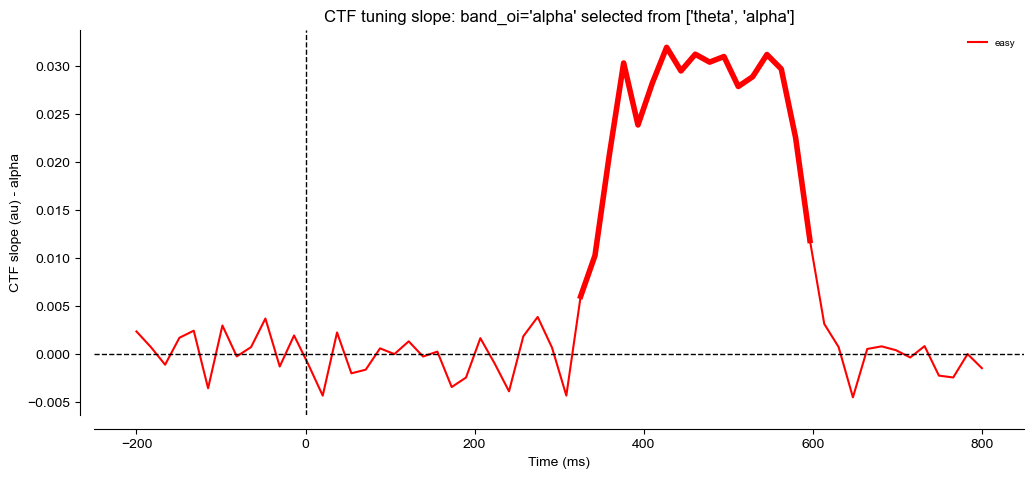

In [17]:
ctf_multiband = make_ctf_result(
    peak_slope=0.03, effect_window=EFFECT_WINDOW, n_subjects=N_SUBJECTS,
    bands=['theta', 'alpha'], cnd='easy', seed=1,
)

fig = plt.figure(figsize=(12, 5))
plot_ctf_timecourse(
    ctf_multiband,
    cnds=['easy'],           # Only condition generated above
    colors=[COLORS['easy']],
    output='raw_slopes',     # Un-fitted linear tuning slope
    band_oi='alpha',         # Select the alpha band only (vs. averaging across bands)
    stats='perm',            # Cluster-based permutation test vs. zero
)
plt.title("CTF tuning slope: band_oi='alpha' selected from ['theta', 'alpha']")
display(fig)
plt.close('all')

### 5.4 GAT and Time-Frequency CTF Modes

Times converted from seconds to milliseconds


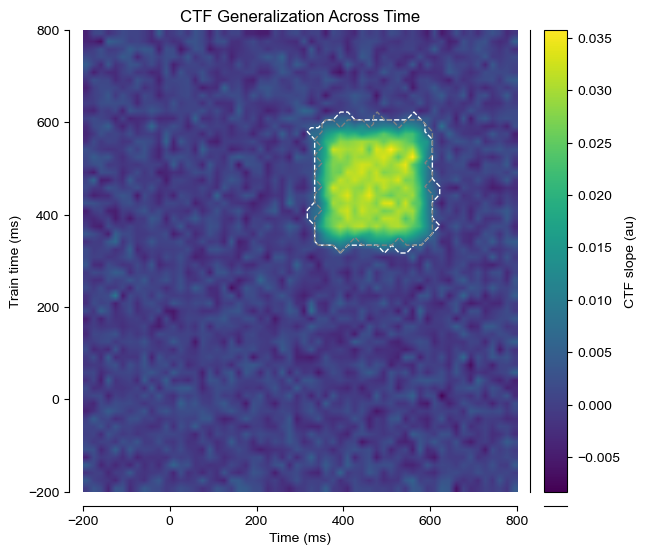

Times converted from seconds to milliseconds


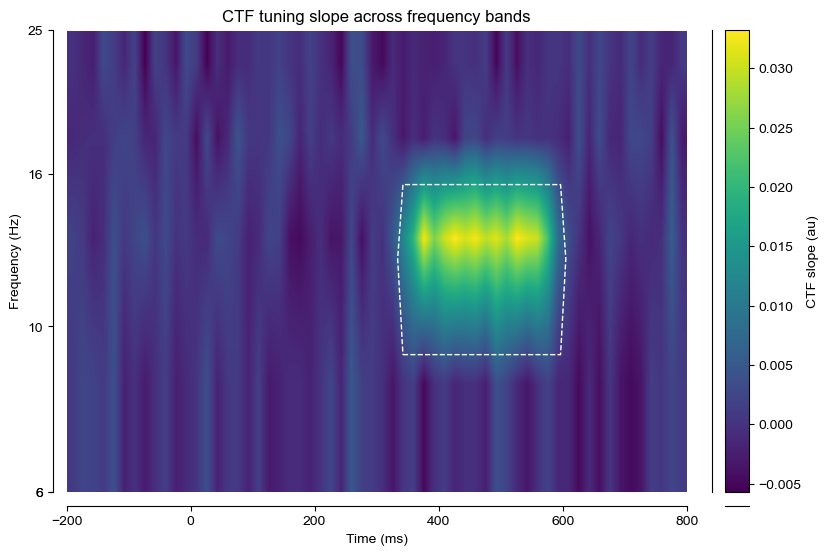

In [18]:
ctf_gat_easy = make_ctf_result(peak_slope=0.03, shape='gat', effect_window=EFFECT_WINDOW,
                               n_subjects=N_SUBJECTS, cnd='easy', seed=1)
ctf_gat_hard = make_ctf_result(peak_slope=0.004, shape='gat', effect_window=EFFECT_WINDOW,
                               n_subjects=N_SUBJECTS, cnd='hard', seed=3)
ctfs_gat = [dict(e, **h) for e, h in zip(ctf_gat_easy, ctf_gat_hard)]

fig = plt.figure(figsize=(7, 6))
plot_ctf_timecourse(
    ctfs_gat,
    cnds=['easy'],               # 2D mode only supports one condition
    timecourse='2d_gat',         # Generalization matrix (train time x test time)
    output='raw_slopes',         # Un-fitted linear tuning slope
    stats='perm',                # Cluster-based permutation test vs. zero
    cnd_diff=('easy', 'hard'),   # Overlay contour where 'easy' and 'hard' differ
)
plt.title("CTF Generalization Across Time")
display(fig)
plt.close('all')

ctf_tfr_easy = make_ctf_result(peak_slope=0.03, shape='tfr', effect_window=EFFECT_WINDOW,
                               n_subjects=N_SUBJECTS, cnd='easy', seed=1)

fig = plt.figure(figsize=(10, 6))
plot_ctf_timecourse(
    ctf_tfr_easy,
    cnds=['easy'],           # Only condition generated above
    timecourse='2d_tfr',     # 2D frequency x time heatmap
    output='raw_slopes',     # Un-fitted linear tuning slope
    stats='perm',            # Cluster-based permutation test vs. zero
)
plt.title("CTF tuning slope across frequency bands")
display(fig)
plt.close('all')

---

## Section 6: Summary and Next Steps

### What You've Seen

1. ✅ **ERP**: Lateralized 1D waveforms, three statistical test methods compared, condition-difference marker
2. ✅ **TFR**: 2D heatmaps with `mask_nonsig`, 1D frequency-band timecourses, `cnd_diff` in both 1D and 2D form
3. ✅ **BDM**: 1D decoding, multi-contrast `cnd_diff`, GAT with diverging colormap, time-frequency decoding
4. ✅ **CTF**: 1D tuning slopes, `band_oi` selection, GAT/TFR CTF modes, `cnd_diff` contour overlay

### What "Good" Looks Like

Every figure above shows a **guaranteed-significant** effect -- that's the point. When you move to real data, don't expect every analysis to look this clean: with a real, modest-sized sample (like the 7-subject dataset used from `01_preprocessing.ipynb` onward), many effects will be smaller, noisier, or simply not reach significance. That's not a sign anything is broken -- it's a sign you have real, variable human data. Use what you saw here as a reference for *what the plot itself should look like when there is a clean effect to find*, not as an expectation for every result.

### Next Steps

Now that you've seen every plotting and statistics option available, start the real analysis workflow:

1. **Preprocessing** → `01_preprocessing.ipynb`
2. **ERP Analysis** → `02_erp_analysis.ipynb`
3. **Time-Frequency Analysis** → `03_tfr_analysis.ipynb` / `04_tfr_advanced.ipynb`
4. **Multivariate Decoding** → `05_bdm_decoding.ipynb` / `06_bdm_advanced.ipynb`
5. **Spatial Encoding (CTF)** → `07_ctf_analysis.ipynb` / `08_ctf_advanced.ipynb`